In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score
from statistics import mean
import joblib
from sklearn.metrics import accuracy_score

In [2]:
# Remove unnecessary columns
def clean_csv(old_filename, new_filename, remove_col_list):
    try:
        df = pd.read_csv(old_filename)
        df.drop(columns=remove_col_list, inplace=True)
        df.to_csv(new_filename, index=False)

        print(f'file: "{old_filename}" cleaned successfully')
        return True
    except Exception as e:
        print(f'file: "{old_filename}" clean failed ({e})')
        return False

In [3]:
# Loads features and target variables
def load_data(filename, y_target_name, num_rows=-1, pos=0):
    df = pd.read_csv(filename)
    if num_rows > 0:
        df = df[pos : pos + num_rows]
    elif pos != 0:
        df = df[pos:]

    X = df.drop(columns=[y_target_name])
    y = df[y_target_name]

    return X, y, df

In [4]:
def show_corr_matrix(df, output_filename):
    non_valid_cols = [
        df.columns[i]
        for i, item in enumerate(df.dtypes)
        if not pd.api.types.is_numeric_dtype(item)
    ]
    df.drop(columns=non_valid_cols, inplace=True)
    matrix = df.corr()
    plt.figure(figsize=(32, 16))
    sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("UCI Phishing URL Correlation Heatmap")
    plt.savefig(output_filename)

In [5]:
def get_training_test_data(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
    return X_train, X_test, y_train, y_test

In [6]:
def logistic_regression_model_training(X_train, X_test, y_train, y_test):
    C_grid = np.logspace(-4, 4, 20)
    y_train_log_loss_data = []
    y_test_log_loss_data = []
    for i, C in enumerate(C_grid):
        print(f"working on {i}")
        clf = LogisticRegression(C=C, l1_ratio=0, solver="lbfgs", max_iter=500).fit(
            X_train, y_train
        )
        y_train_pred = clf.predict_proba(X_train)
        y_test_pred = clf.predict_proba(X_test)
        y_train_log_loss = log_loss(y_train, y_train_pred)
        y_test_log_loss = log_loss(y_test, y_test_pred)

        # print(f"{y_train_pred=}")
        # print(f"{y_test_pred=}")
        print(f"{y_train_log_loss=}")
        print(f"{y_test_log_loss=}")
        y_train_log_loss_data.append(y_train_log_loss)
        y_test_log_loss_data.append(y_test_log_loss)

    plt.figure()
    plt.plot(
        C_grid,
        y_train_log_loss_data,
        "o-",
        color="blue",
        label="Training Data Log-Loss",
        markersize=3,
    )
    plt.plot(
        C_grid,
        y_test_log_loss_data,
        "o-",
        color="red",
        label="Test Data Log-Loss",
        markersize=3,
    )

    plt.xlabel("C")
    plt.ylabel("Log-Loss")
    plt.title("Log-Loss of Training and Test Data Vs C")
    # plt.ylim([0, 1])
    plt.xscale("log")
    plt.legend()
    plt.savefig("./outputs/logistic_regression_log_loss_c.png")
    return clf

In [ ]:
clean_csv(
    "./data/uci_phishing_url_dataset.csv",
    "./data/uci_phishing_url_dataset_clean.csv",
    [
        "URL",
        "Domain",
        "TLD",
        "Title",
        "HasTitle",
        "DomainTitleMatchScore",
        "URLTitleMatchScore",
        "HasFavicon",
        "Robots",
        "IsResponsive",
        "NoOfURLRedirect",
        "NoOfSelfRedirect",
        "HasDescription",
        "NoOfPopup",
        "NoOfiFrame",
        "HasExternalFormSubmit",
        "HasSocialNet",
        "HasSubmitButton",
        "HasHiddenFields",
        "HasPasswordField",
        "Bank",
        "Pay",
        "Crypto",
        "HasCopyrightInfo",
        "NoOfImage",
        "NoOfCSS",
        "NoOfJS",
        "NoOfSelfRef",
        "NoOfEmptyRef",
        "NoOfExternalRef",
        "URLSimilarityIndex",
        "CharContinuationRate",
        "TLDLegitimateProb",
        "URLCharProb",
    ],
)

file: "./data/uci_phishing_url_dataset.csv" cleaned successfully


True

remove "FILENAME" column from data


In [8]:
X, y, df = load_data("./data/uci_phishing_url_dataset_clean.csv", "IsLegit", 100000)

X[X["NoOfObfuscatedChar"] > 0]

,URLLength,DomainLength,IsDomainIP,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDigitsInURL,DigitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength
77,92,16,0,3,1,1,9,0.098,35,0.380,39,0.424,0,0,3,7,0.109,1,3,204
903,126,74,0,4,2,1,3,0.024,98,0.778,11,0.087,0,1,1,7,0.071,1,127,1198
1093,188,14,0,3,1,1,3,0.016,118,0.628,31,0.165,4,1,3,11,0.101,1,2,1579
3771,57,19,0,3,1,1,3,0.053,39,0.684,2,0.035,0,0,1,7,0.140,1,219,439
4215,65,21,0,2,1,1,3,0.046,50,0.769,2,0.031,0,0,1,5,0.092,0,9,117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97256,49,29,0,3,1,1,3,0.061,33,0.673,3,0.061,0,0,1,4,0.102,1,88,9703
97422,62,33,0,3,3,1,3,0.048,44,0.710,2,0.032,0,0,1,7,0.129,1,1504,85411
98363,170,18,0,3,1,1,3,0.018,123,0.724,14,0.082,2,1,2,9,0.082,1,51,206
98377,215,52,0,3,3,1,12,0.056,135,0.628,43,0.200,1,1,12,12,0.121,0,474,780


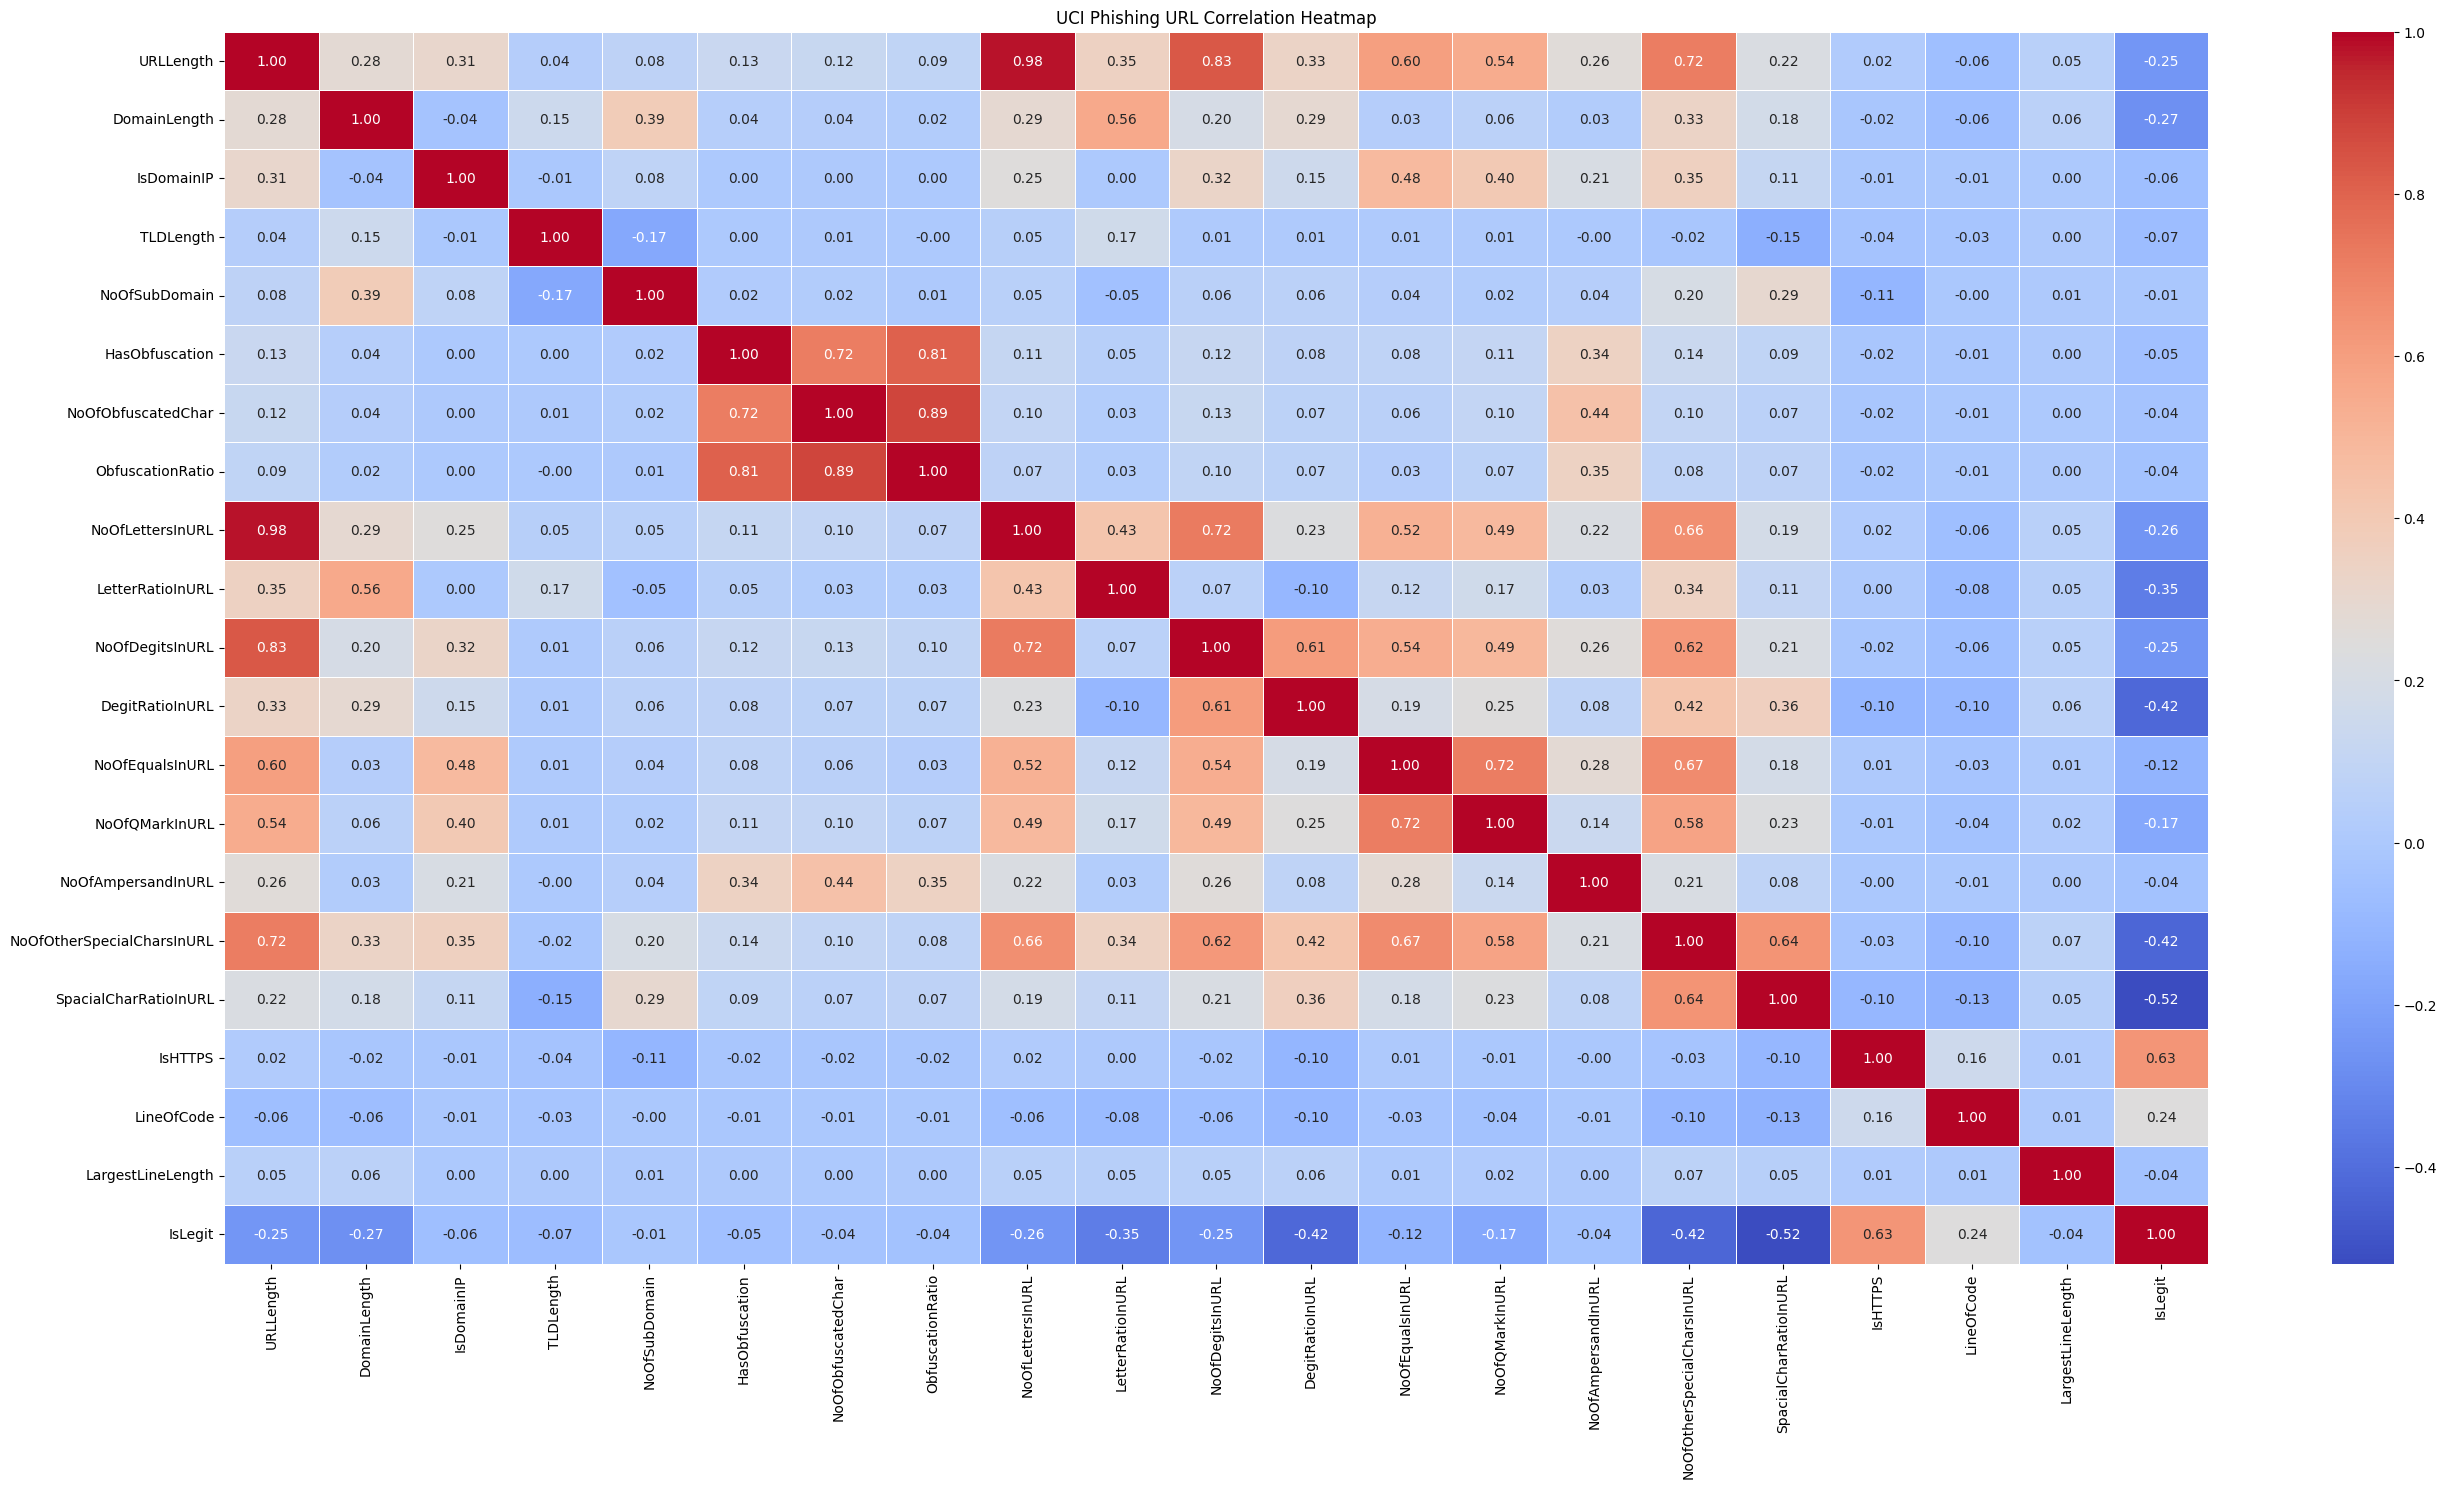

In [9]:
show_corr_matrix(df, "./outputs/uci_phishing_url_corr_matrix.png")

working on 0


/home/otter/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1213: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/otter/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/otter/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1213: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


y_train_log_loss=0.0379018316284987
y_test_log_loss=0.040516339464230215
working on 1


/home/otter/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/home/otter/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1213: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


y_train_log_loss=0.032813782411808094
y_test_log_loss=0.035588832957602574
working on 2


...

y_train_log_loss=0.002448675034651246
y_test_log_loss=0.0014743794517679887
working on 18


/home/otter/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1213: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/home/otter/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


y_train_log_loss=0.002243192454168101
y_test_log_loss=0.0015521503783319445
working on 19


/home/otter/.local/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1213: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


y_train_log_loss=0.0024485170979031334
y_test_log_loss=0.0014716156979675415


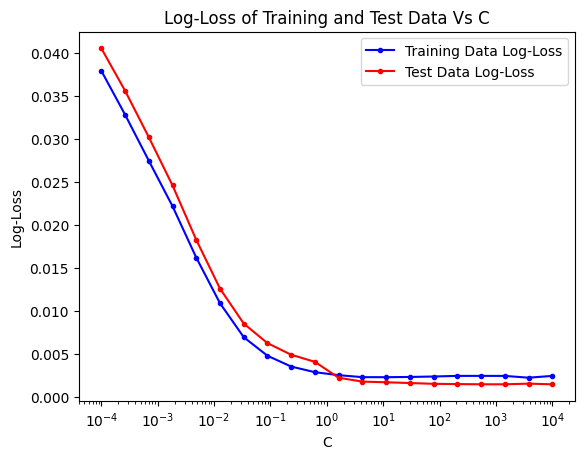

In [10]:
X_train, X_test, y_train, y_test = get_training_test_data(X, y)
clf = logistic_regression_model_training(X_train, X_test, y_train, y_test)

In [13]:
joblib.dump(clf, "./models/logit_model.pkl")

['./models/logit_model.pkl']

In [14]:
clf2 = joblib.load("./models/logit_model.pkl")
X_new, y_new, df_new = load_data(
    "./data/uci_phishing_url_dataset_clean.csv", "IsLegit", pos=100000
)
print(clf2.coef_)
y_new_pred = clf2.predict(X_new)

accuracy = accuracy_score(y_new, y_new_pred)
print(f"Accuracy: {accuracy}")

[[-1.31011175e+01  2.69573796e+01 -2.64945966e-02 -5.11000440e-01
  -1.93815194e+00 -2.64841696e-02 -1.10612145e-01 -1.22438795e-03
  -1.39888069e+01 -4.11179490e-01 -1.49315336e+01 -1.78068544e-01
  -2.93976238e-01 -2.73264771e-01 -5.65209187e-02 -1.35415090e+01
  -5.14651152e-01  2.78938366e+01  3.78837538e-02 -4.66235208e-04]]
Accuracy: 0.999668618137634


In [ ]:
import re
from urllib.parse import urlparse, urlsplit
import tldextract
import pandas as pd
from typing import *
import requests

# Given a url get these feature data
# Then return a np.array of those features


# def preprocess_data(self, self, url: str):
class preprocess_data:
    url_len = 0
    num_digit = 0
    func_pointer: List[Callable]
    url: str = ""
    numObfuscatedChar = 0
    headers = {
        "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120 Safari/537.36"
    }

    def __init__(self, url: str):
        self.url_len = len(url)
        self.url = url

    def get_data(self) -> pd.DataFrame:
        func_pointer = [
            [self.URLLength, "URLLength"],
            [self.DomainLength, "DomainLength"],
            [self.IsDomainIP, "IsDomainIP"],
            [self.TLDLength, "TLDLength"],
            [self.NoOfSubDomain, "NoOfSubDomain"],
            [self.HasObfuscation, "HasObfuscation"],
            [self.NoOfObfuscatedChar, "NoOfObfuscatedChar"],
            [self.ObfuscationRatio, "ObfuscationRatio"],
            [self.NoOfLettersInURL, "NoOfLettersInURL"],
            [self.LetterRatioInURL, "LetterRatioInURL"],
            [self.NoOfDigitsInURL, "NoOfDigitsInURL"],
            [self.DigitRatioInURL, "DigitRatioInURL"],
            [self.NoOfEqualsInURL, "NoOfEqualsInURL"],
            [self.NoOfQMarkInURL, "NoOfQMarkInURL"],
            [self.NoOfAmpersandInURL, "NoOfAmpersandInURL"],
            [self.NoOfOtherSpecialCharsInURL, "NoOfOtherSpecialCharsInURL"],
            [self.SpecialCharRatioInURL, "SpecialCharRatioInURL"],
            [self.IsHTTPS, "IsHTTPS"],
            [self.LineOfCode, "LineOfCode"],
            [self.LargestLineLength, "LargestLineLength"],
        ]
        # TODO: Add other function here

        dat = {}
        # THIS IS WHERE DF FROM URL IS MADE
        # TODO: POTENTIAL OPTIMISATION FOR SPEED POSSIBLE HERE!
        for x in func_pointer:
            # print((x[1], x[0](self.url)))
            dat[x[1]] = [x[0](self.url)]
        return pd.DataFrame(dat)

    def URLLength(self, url: str):
        return len(url)

    def DomainLength(self, url: str):
        domain = urlparse(url).netloc
        return len(domain)

    def IsDomainIP(self, url: str):
        parsed_url = urlsplit(url)
        regexIPV4 = r"\d+\.\d+\.\d+\.\d+"
        regexIPV6 = r"/^([0-9a-fA-F]{1,4}:){7}[0-9a-fA-F]{1,4}$/"

        ipv4 = re.match(regexIPV4, str(parsed_url.hostname))
        ipv6 = re.match(regexIPV6, str(parsed_url.hostname))
        return 1 if (ipv6 is None) or (ipv4 is None) else 0

    def TLDLength(self, url: str):
        extracted = tldextract.extract(url)
        tld = extracted.suffix
        return len(tld)

    def NoOfSubDomain(self, url: str):
        extracted = tldextract.extract(url)
        if extracted.subdomain == "":
            return 0
        return len(extracted.subdomain.split("."))

    def HasObfuscation(self, url: str):
        # URL obfuscation according to this article
        # https://pushsecurity.com/blog/detecting-phishing-pages-using-obfuscated-url-destinations
        # is any character after the @ symbol
        # WRONG => DATA SET USES HTML ENCODING FOR DETECTION
        regex = r"%[0-9a-fA-F]{2}"
        return 1 if re.search(regex, url) is not None else 0

    def NoOfObfuscatedChar(self, url: str):
        regex = r"%[0-9a-fA-F]{2}"
        found = re.findall(regex, url)
        # HTML encoding always comes in triplets
        # eg: %01 or %0A or %10
        return len(found) * 3

    def ObfuscationRatio(self, url: str):
        return self.NoOfObfuscatedChar(url) / len(url) if len(url) > 0 else 0

    def NoOfLettersInURL(self, url: str):
        # Count number of unique letters!
        ht = set()
        for c in url:
            if c.isalpha():
                ht.add(c)

        return len(ht)

    def LetterRatioInURL(self, url: str):
        return self.NoOfLettersInURL(url) / len(url) if len(url) > 0 else 0

    def NoOfDigitsInURL(self, url: str):
        return sum(c.isdigit() for c in url)

    def DigitRatioInURL(self, url: str):
        return self.NoOfDigitsInURL(url) / len(url) if len(url) > 0 else 0

    def NoOfEqualsInURL(self, url: str):
        return sum(c in "=" for c in url)

    def NoOfQMarkInURL(self, url: str):
        return sum(c in "?" for c in url)

    def NoOfAmpersandInURL(self, url: str):
        return sum(c in "&" for c in url)

    def NoOfOtherSpecialCharsInURL(self, url: str):
        special = "!@#$%^*()_+-[]{}|;:'\",<>~`"
        return sum(c in special for c in url)

    def SpecialCharRatioInURL(self, url: str):
        total_special = (
            self.NoOfEqualsInURL(url)
            + self.NoOfQMarkInURL(url)
            + self.NoOfAmpersandInURL(url)
            + self.NoOfOtherSpecialCharsInURL(url)
        )

        return total_special / len(url) if len(url) > 0 else 0

    def IsHTTPS(self, url: str):
        return 1 if url.strip().lower().startswith("https://") else 0

    # TODO: ASK+CHECK WITH KELLY ABOUT THESE TWO FIELDS
    # IF U CANNOT FETCH FROM WEBSITE THEN IT SHOULD RETURN FALSE
    def LineOfCode(self, url: str):
        # TODO: REDIRECTS ARE BAD HERE
        try:
            r = requests.get(
                url, allow_redirects=True, timeout=10, headers=self.headers
            )
            self.page_data = r.text.splitlines()
            return len(r.text.splitlines())
        except Exception as err:
            print(err)
            self.page_data = []
            return 0
            # Check if request failed!

    def LargestLineLength(self, url: str):
        return max((len(line) for line in self.page_data), default=0)


# TODO: Gotta run the class
tmp_example = "wtf.com"
obfuscation = "https://s3.amazonaws.com/appforest_uf/f1678949673383x832048620362898600/index%20%284%29.html"
safe = "https://www.saffronart.com"
example = preprocess_data(obfuscation)
safeURL = preprocess_data(safe)
obfuscated = example.get_data()
s = safeURL.get_data()

In [90]:
s

,URLLength,DomainLength,IsDomainIP,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDigitsInURL,DigitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength
0,26,18,1,3,1,0,0,0.0,12,0.461538,0,0.0,0,0,0,1,0.038462,1,1216,14146


In [91]:
obfuscated

,URLLength,DomainLength,IsDomainIP,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,NoOfLettersInURL,LetterRatioInURL,NoOfDigitsInURL,DigitRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,NoOfAmpersandInURL,NoOfOtherSpecialCharsInURL,SpacialCharRatioInURL,IsHTTPS,LineOfCode,LargestLineLength
0,92,16,1,3,1,1,9,0.097826,19,0.206522,39,0.423913,0,0,0,5,0.054348,1,2,224


In [97]:
clf2.predict(s)

array([1])

In [ ]:
clf2.predict(obfuscated)[0]

np.int64(0)